In [ ]:
# Лабораторна робота 9
# Байков Олександр
# Був присутній на парі


In [1]:
# Завантаження бібліотек
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!pip install -q pyspark

In [8]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["PYSPARK_PYTHON"] = "/usr/bin/python3"

In [4]:
from pyspark.sql import SparkSession

In [7]:
from google.colab import files
uploaded = files.upload()

Saving stocks_price_final.csv to stocks_price_final.csv


In [9]:
spark = SparkSession.builder \
    .appName("Stock Analysis") \
    .getOrCreate()

In [11]:
df = spark.read.csv("stocks_price_final.csv", header=True, inferSchema=True)
df.printSchema()
df.show(5)

root
 |-- _c0: integer (nullable = true)
 |-- symbol: string (nullable = true)
 |-- date: date (nullable = true)
 |-- open: string (nullable = true)
 |-- high: string (nullable = true)
 |-- low: string (nullable = true)
 |-- close: string (nullable = true)
 |-- volume: string (nullable = true)
 |-- adjusted: string (nullable = true)
 |-- market.cap: string (nullable = true)
 |-- sector: string (nullable = true)
 |-- industry: string (nullable = true)
 |-- exchange: string (nullable = true)

+---+------+----------+---------+---------+---------+---------+-------+---------+----------+-------------+--------------------+--------+
|_c0|symbol|      date|     open|     high|      low|    close| volume| adjusted|market.cap|       sector|            industry|exchange|
+---+------+----------+---------+---------+---------+---------+-------+---------+----------+-------------+--------------------+--------+
|  1|   TXG|2019-09-12|       54|       58|       51|    52.75|7326300|    52.75|    $9.31B|C

In [17]:
from pyspark.sql.functions import col, sum, min, max

In [18]:
# Завдання 1
print("Кількість рядків:", df.count())
print("Кількість стовпців:", len(df.columns))


Кількість рядків: 1729034
Кількість стовпців: 13


In [20]:
# Завдання 2
for col_name in df.columns:
    if "." in col_name:
        df = df.withColumnRenamed(col_name, col_name.replace(".", "_"))

In [21]:
df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()


+---+------+----+----+----+---+-----+------+--------+----------+------+--------+--------+
|_c0|symbol|date|open|high|low|close|volume|adjusted|market_cap|sector|industry|exchange|
+---+------+----+----+----+---+-----+------+--------+----------+------+--------+--------+
|  0|     0|   0|   0|   0|  0|    0|     0|       0|         0|     0|       0|       0|
+---+------+----+----+----+---+-----+------+--------+----------+------+--------+--------+



In [23]:
# Завдання 3
df.select("symbol").distinct().show()

+------+
|symbol|
+------+
|  ALXN|
|  BAND|
|  BROG|
|  CBIO|
|  HBNC|
|  LEGH|
|  MORF|
|   NIU|
|  PSTX|
|  RPTX|
|  ABMD|
|   APM|
|  BCOV|
|  BYFC|
|  EOLS|
|  EYEN|
|  FTEK|
|  IOSP|
|  KNDI|
|  LLNW|
+------+
only showing top 20 rows



In [24]:
# Завдання 4
df.select(min("close").alias("Мін. ціна"), max("close").alias("Макс. ціна")).show()

+---------+----------+
|Мін. ціна|Макс. ціна|
+---------+----------+
|    0.071|        NA|
+---------+----------+



In [30]:
# Завдання 5
from pyspark.sql.types import DoubleType
numeric_columns = ["open", "high", "low", "close", "volume", "adjusted", "market_cap"]
# Перетворення колонок у DoubleType
for col_name in numeric_columns:
    if col_name in df.columns:
        df = df.withColumn(col_name, col(col_name).cast(DoubleType()))


In [31]:
df.groupBy("symbol").avg("close").withColumnRenamed("avg(close)", "Середня ціна").show()

+------+------------------+
|symbol|      Середня ціна|
+------+------------------+
|  ALXN| 112.7071684489796|
|  BAND| 74.14515299999998|
|  BROG|10.259650510204096|
|  CBIO|6.9568112244897975|
|  HBNC|15.349744897959189|
|  LEGH| 13.31544641836734|
|  MORF|18.446425970370363|
|   NIU| 8.957015311224499|
|  PSTX|14.947777777777778|
|  RPTX|27.669565260869557|
|  ABMD|228.89303535204076|
|   APM|13.568482153061222|
|  BCOV| 9.076326530612242|
|  BYFC|1.5309948979591834|
|  EOLS|13.751250015306125|
|  EYEN|3.8945076530612233|
|  FTEK|1.1210969387755108|
|  IOSP| 84.54204086479585|
|  KNDI| 4.712857142857143|
|  LLNW|  3.96658163265306|
+------+------------------+
only showing top 20 rows



In [32]:
# Завдання 6
df.groupBy("symbol").count().orderBy("count", ascending=False).show()

+------+-----+
|symbol|count|
+------+-----+
|   RRD|  784|
|  INFO|  784|
|  NCLH|  784|
|  GOLD|  784|
|  PGTI|  784|
|  EGHT|  784|
|  QGEN|  784|
|  AMOV|  784|
|  CNMD|  784|
|  AMBC|  784|
|  SAVE|  784|
|  UNFI|  784|
|  PRMW|  422|
|  BRKR|  392|
|  ALXN|  392|
|  OPRX|  392|
|  RGLD|  392|
|  CBIO|  392|
|  SABR|  392|
|  LEGH|  392|
+------+-----+
only showing top 20 rows



In [41]:
import pandas as pd
import matplotlib.pyplot as plt
company_pd = company_df.select("date", "close", "volume").orderBy("date").toPandas()
company_pd["date"] = pd.to_datetime(company_pd["date"])

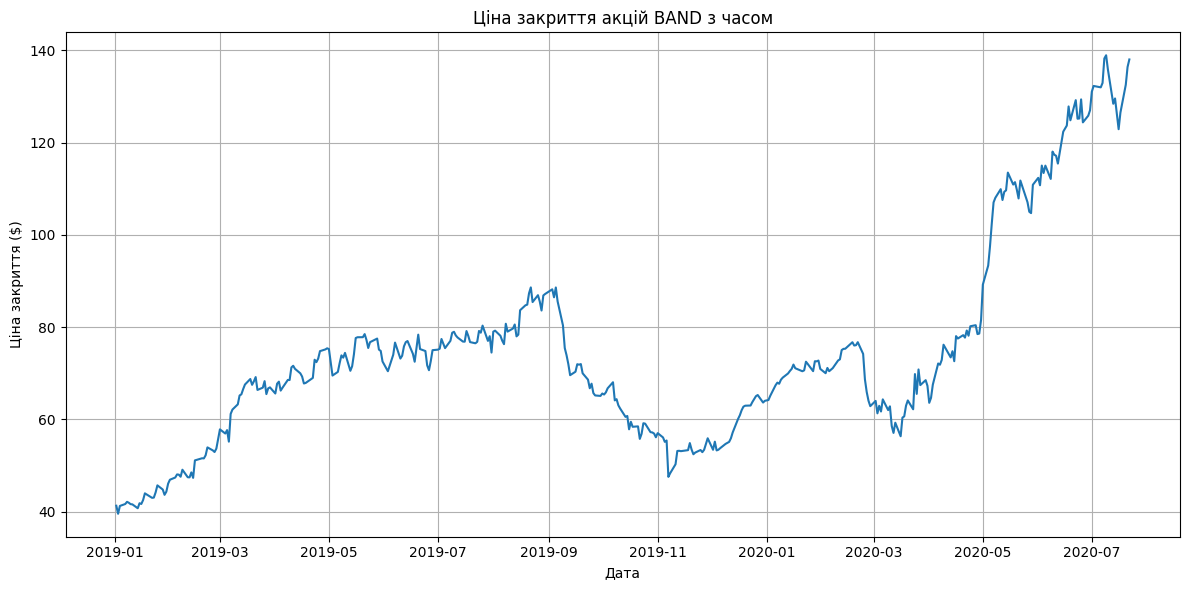

In [42]:
# Завдання 7
plt.figure(figsize=(12,6))
plt.plot(company_pd["date"], company_pd["close"])
plt.title("Ціна закриття акцій BAND з часом")
plt.xlabel("Дата")
plt.ylabel("Ціна закриття ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

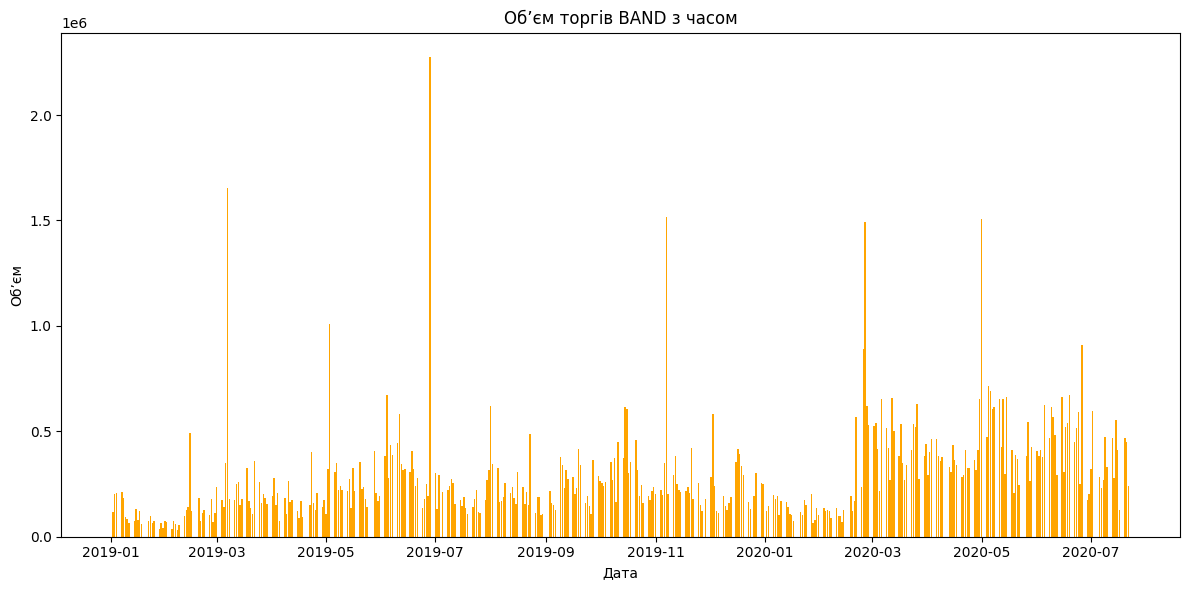

In [43]:
# Завдання 8
plt.figure(figsize=(12,6))
plt.bar(company_pd["date"], company_pd["volume"], color='orange')
plt.title("Обʼєм торгів BAND з часом")
plt.xlabel("Дата")
plt.ylabel("Обʼєм")
plt.tight_layout()
plt.show()

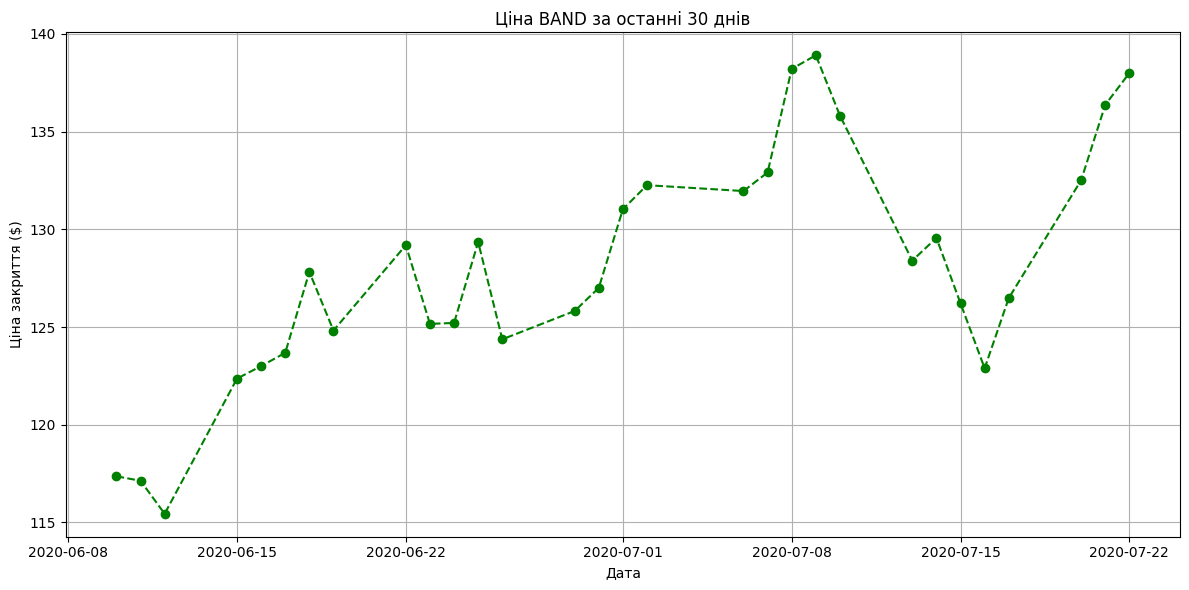

In [44]:
# Завдання 9
last_30 = company_pd.sort_values("date").tail(30)
plt.figure(figsize=(12,6))
plt.plot(last_30["date"], last_30["close"], marker='o', linestyle='--', color='green')
plt.title("Ціна BAND за останні 30 днів")
plt.xlabel("Дата")
plt.ylabel("Ціна закриття ($)")
plt.grid(True)
plt.tight_layout()
plt.show()